In [1]:
import numpy as np
import cv2 as cv2
import torch
from ultralytics import YOLO
import time

In [ ]:
import pycaw.pycaw as pycaw
from ctypes import cast, POINTER
from comtypes import CLSCTX_ALL

In [175]:
model = YOLO("yolo11n.pt")

In [81]:
model.model.model[0].conv.weight *= 10
model.model.model[0].conv.weight

Parameter containing:
tensor([[[[-2.7524e+01, -3.8761e+00,  3.5656e+01],
          [-6.9695e+01, -9.1664e+00,  7.3533e+01],
          [-4.9115e+01, -3.9645e+00,  5.4948e+01]],

         [[-3.2625e+01, -4.7473e+00,  4.0832e+01],
          [-8.4896e+01, -1.3737e+01,  8.2119e+01],
          [-4.2423e+01, -1.5814e+00,  5.1766e+01]],

         [[-1.0928e+01, -2.0391e+00,  9.2674e+00],
          [-3.3484e+01, -1.2500e+00,  3.1539e+01],
          [-1.5795e+01,  3.2606e+00,  1.9999e+01]]],


        [[[-4.4269e+01, -3.0191e+01, -9.9484e+00],
          [-4.2506e+01, -4.7389e+01, -2.9269e+01],
          [-1.9178e+01, -2.5525e+01, -1.1929e+01]],

         [[ 2.1714e+01,  1.0423e+01,  5.3845e+00],
          [ 1.2742e+01,  7.2561e+00,  4.3978e+00],
          [ 3.1500e+00, -1.6971e+00, -2.7278e+00]],

         [[ 2.5674e+01,  2.0656e+01,  6.7509e+00],
          [ 2.8807e+01,  3.7569e+01,  2.3382e+01],
          [ 1.6967e+01,  2.3966e+01,  1.3570e+01]]],


        [[[ 3.4902e+01,  5.2224e+00, -3.3588

In [179]:
image = cv2.imread(r"C:\Users\ASUS\Pictures\track.jpg")

In [183]:
# Convert BGR to HSV
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
 
    # define range of blue color in HSV
lower_blue = np.array([90,50,50])
upper_blue = np.array([130,255,255])
 
    # Threshold the HSV image to get only blue colors
mask = cv2.inRange(hsv, lower_blue, upper_blue)
 
    # Bitwise-AND mask and original image
res = cv2.bitwise_and(image,image, mask= mask)

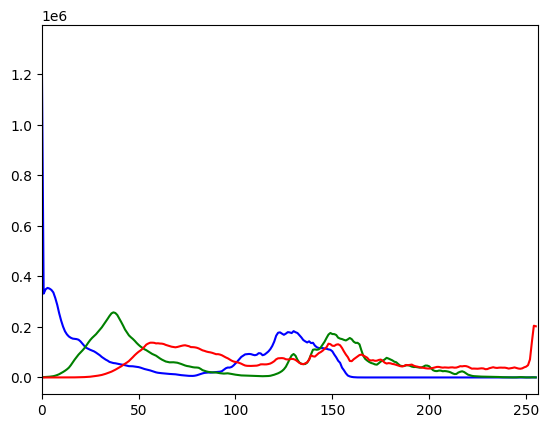

In [190]:
import numpy as np
from matplotlib import pyplot as plt
 
img = cv2.imread(r"C:\Users\ASUS\Pictures\sunset.jpg")
hsv = cv2.cvtColor(img,cv2.COLOR_BGR2HSV)
assert img is not None, "file could not be read, check with os.path.exists()"
color = ('b','g','r')
for i,col in enumerate(color):
    histr = cv2.calcHist([img],[i],None,[256],[0,256])
    plt.plot(histr,color = col)
    plt.xlim([0,256])
plt.show()

In [184]:
cv2.imshow('frame',res)
cv2.waitKey()
cv2.destroyAllWindows()

In [ ]:
model()


image 1/1 C:\Users\ASUS\Pictures\track.jpg: 640x480 8 persons, 4 cars, 1 truck, 64.1ms
Speed: 3.8ms preprocess, 64.1ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 480)


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

In [ ]:
def gesture_old(recording = False):
    cap = cv.VideoCapture(0)

    if not cap.isOpened():
        print('Камера недоступна')
        return
    

    if recording:
        fourcc = cv.VideoWriter_fourcc(*'XVID')
        fps = 20.0
        width = int(cap.get(cv.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv.CAP_PROP_FRAME_HEIGHT))

        out = cv.VideoWriter('output.avi', fourcc, fps, (width, height))

    ret, frame = cap.read()

    model = YOLO("yolo11n.pt")

    time_t = time.time()

    frame_after = frame.copy()

    while cap.isOpened():
        ret, frame = cap.read()
        #frame = cv.resize(frame, (640, 480))

        if not ret:
            break
        if cv.waitKey(1) & 0xFF == ord('q'):
            break
        
        if time.time() - time_t >= 1:
            print(1)
            time_t = time.time()
        
            results = model(frame)
            frame_after = frame.copy()
            for i,result in enumerate (results):
                xyxy = result.boxes.xyxy
                for ix,iy,x,y in xyxy: 
                    ix = int(ix)
                    iy = int(iy)
                    x = int(x)
                    y = int(y)
                    cv.rectangle(frame_after,(ix,iy),(x,y),(0,255,0),5)
        
        
        cv.imshow('frame_after', frame_after)
        cv.imshow('frame', frame)
        
        
        if recording:
            out.write(frame)
    cap.release()
    if recording:
            out.release()
            
    cv.destroyAllWindows()


In [5]:
def gesture(recording = False):
    cap = cv.VideoCapture(0)

    if not cap.isOpened():
        print('Камера недоступна')
        return
    

    if recording:
        fourcc = cv.VideoWriter_fourcc(*'XVID')
        fps = 20.0
        width = int(cap.get(cv.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv.CAP_PROP_FRAME_HEIGHT))

        out = cv.VideoWriter('output.avi', fourcc, fps, (width, height))

    ret, frame = cap.read()

    model = YOLO("yolo11n-pose.pt")

    time_t = time.time()

    frame_after = frame.copy()

    while cap.isOpened():
        ret, frame = cap.read()
        frame = cv.resize(frame, (640, 480))

        if not ret:
            break
        if cv.waitKey(1) & 0xFF == ord('q'):
            break
        
        if time.time() - time_t >= 1:
            print(1)
            time_t = time.time()
        
            results = model(frame)
            frame_after = frame.copy()
            for i,result in enumerate (results):
                xy = result.keypoints.xy
                for x,y in xy[0]:
                    #print(x,y)
                    cv.circle(frame_after, (int(x),int(y)), 1, (255, 0, 0), -1)
        
        
            cv.imshow('frame_after', frame_after)
        cv.imshow('frame', frame)
        
        
        if recording:
            out.write(frame)
    cap.release()
    if recording:
            out.release()
            
    cv.destroyAllWindows()


In [ ]:
def set_system_volume(level):
    """Установить уровень громкости (0.0 - 1.0)"""
    devices = pycaw.AudioUtilities.GetSpeakers()
    interface = devices.Activate(
        pycaw.IAudioEndpointVolume._iid_, CLSCTX_ALL, None)
    volume = cast(interface, POINTER(pycaw.IAudioEndpointVolume))
    volume.SetMasterVolumeLevelScalar(level, None)

def get_system_volume():
    """Получить текущий уровень громкости"""
    devices = pycaw.AudioUtilities.GetSpeakers()
    interface = devices.Activate(
        pycaw.IAudioEndpointVolume._iid_, CLSCTX_ALL, None)
    volume = cast(interface, POINTER(pycaw.IAudioEndpointVolume))
    return volume.GetMasterVolumeLevelScalar()

In [6]:
gesture(recording=False)

1

0: 480x640 1 person, 155.7ms
Speed: 3.2ms preprocess, 155.7ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)
1

0: 480x640 1 person, 143.3ms
Speed: 3.9ms preprocess, 143.3ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)
1

0: 480x640 1 person, 231.2ms
Speed: 3.8ms preprocess, 231.2ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
1

0: 480x640 1 person, 121.9ms
Speed: 2.4ms preprocess, 121.9ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
1

0: 480x640 1 person, 160.1ms
Speed: 3.6ms preprocess, 160.1ms inference, 2.2ms postprocess per image at shape (1, 3, 480, 640)
1

0: 480x640 1 person, 167.9ms
Speed: 2.8ms preprocess, 167.9ms inference, 2.6ms postprocess per image at shape (1, 3, 480, 640)
1

0: 480x640 1 person, 164.0ms
Speed: 4.3ms preprocess, 164.0ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)
1

0: 480x640 1 person, 176.0ms
Speed: 3.0ms preprocess, 176.0ms inference, 1.6ms postproc

In [ ]:
'''
import subprocess
from subprocess import call

a = call('tg.bat')
if a == 0: print('Успешно!')
else: print('Не выполнено(')
'''
    
'''  
while True:
    volume = get_system_volume()
    a = int(input())
    if a == 0: UP = False
    if a == 1: UP = True
    if a == 2: break
    volume = volume + 0.1 if UP else volume - 0.1
    volume = 1 if volume > 1 else volume
    volume = 0 if volume < 0 else volume

    set_system_volume(volume)

    print(f"Текущая громкость: {volume}")
'''


'  \nwhile True:\n    volume = get_system_volume()\n    a = int(input())\n    if a == 0: UP = False\n    if a == 1: UP = True\n    if a == 2: break\n    volume = volume + 0.1 if UP else volume - 0.1\n    volume = 1 if volume > 1 else volume\n    volume = 0 if volume < 0 else volume\n\n    set_system_volume(volume)\n\n    print(f"Текущая громкость: {volume}")\n'

In [ ]:
cap = cv.VideoCapture(0)

if not cap.isOpened():
    print('Камера недоступна')
    

ret, frame = cap.read()

frame = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)

frame = cv.GaussianBlur(frame, (5, 5), 0)

kernel = np.ones((5,5),np.uint8)

_, thresh_static = cv.threshold(frame,150,255,0)

thresh_static = cv.morphologyEx(thresh_static, cv.MORPH_OPEN, kernel)
thresh_static = cv.morphologyEx(thresh_static, cv.MORPH_CLOSE, kernel)
time_thresh_static = time.time()

img_hand = cv.imread('hand.png',cv.IMREAD_GRAYSCALE)
time_t = time.time()

img_hand = cv.medianBlur(img_hand,11)


while cap.isOpened():
    ret, frame = cap.read()

    frame = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)

    if cv.waitKey(1) & 0xFF == ord('q'):
        break
    #



    #diff = cv.absdiff(thresh, thresh_static)


    #cv.imshow('thresh150', thresh)
    #cv.imshow('diff', thresh)

    # Initiate ORB detector

    
    orb = cv.ORB_create()
    
    # find the keypoints with ORB
    kp1 = orb.detect(img_hand,None)
    kp2 = orb.detect(result,None)
    # compute the descriptors with ORB
    kp1, des1 = orb.compute(img_hand, kp1)
    kp2, des2 = orb.compute(result, kp2)


    bf = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=True)

    matches = bf.match(des1, des2)
    # Сортировка matches по расстоянию
    matches = sorted(matches, key=lambda x: x.distance)

    threshold = 50

    matches = [m for m in matches if m.distance < threshold]
    img_matches = cv.drawMatches(img_hand,kp1,frame,kp2,matches,
                          None,flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    
    cv.imshow('img_matches', img_matches)
    
    src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

    M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)

    if M is not None:
        h, w, _ = img_hand.shape
        pts = np.float32([[0, 0], [0, h-1], [w-1, h-1], [w-1, 0]]).reshape(-1, 1, 2)
        dst = cv.perspectiveTransform(pts, M)
        img_matches = cv.polylines(frame, [np.int32(dst)], True, 255, 3, cv.LINE_AA)
    

    if not ret:
        break
    
    
    if cv.waitKey(1) & 0xFF == ord('p'):
        cv.imwrite('hand.png', frame)
    
    if time.time() - time_t >= 1:
        time_t = time.time()
    

    #frame1 = frame2

    cv.imshow('frame', frame)

cap.release()
            
cv.destroyAllWindows()

In [17]:
import os
os.getcwd()

'c:\\Users\\Alex\\Documents\\GitHub\\CV-training\\gesture control'

In [22]:
img_hand.shape

(480, 640, 1)